# Classificação multiclasse — Iris

Demonstração de ponta a ponta da rede neural `Rede` (implementada do zero, sem frameworks de ML) na classificação das três espécies de flor Iris: **setosa (0)**, **versicolor (1)** e **virginica (2)**.

**Diferenças em relação ao caso binário:** a saída usa **3 neurônios softmax** com custo **entropia cruzada categórica**, os rótulos são **codificados em one-hot**, e a previsão é o `argmax` da distribuição de probabilidade.

**Pipeline:** carregar → one-hot + divisão treino/validação/teste → treinar → ajustar a taxa de aprendizado na validação → curva de aprendizado → avaliar no teste (acurácia, matriz de confusão 3x3, precisão/revocação/F1 por classe e macro).

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# coloca a raiz do repositorio no path, para importar a biblioteca da api
sys.path.insert(0, os.path.abspath('..'))
from api.main import Rede

## 1. Carregando os dados

O conjunto `mult_iris.csv` tem 150 amostras, 4 atributos numéricos (comprimento/largura de sépala e pétala) e a coluna alvo `Species` (0, 1, 2). As classes são perfeitamente balanceadas (50 de cada).

In [2]:
df = pd.read_csv('../datasets/clean/mult_iris.csv')
print('formato:', df.shape)
print('balanceamento das classes (Species):')
print(df['Species'].value_counts().sort_index())
df.head()

formato: (150, 5)
balanceamento das classes (Species):
Species
0    50
1    50
2    50
Name: count, dtype: int64


,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,-0.900681,1.032057,-1.341272,-1.312977,0
1,-1.143017,-0.124958,-1.341272,-1.312977,0
2,-1.385353,0.337848,-1.398138,-1.312977,0
3,-1.506521,0.106445,-1.284407,-1.312977,0
4,-1.021849,1.263460,-1.341272,-1.312977,0


## 2. Preparação dos dados

Os atributos já vêm padronizados (média 0, desvio 1). Para a saída softmax precisamos dos rótulos em **one-hot** (um vetor `[1,0,0]`, `[0,1,0]` ou `[0,0,1]`), que é o formato esperado pela entropia cruzada categórica. Guardamos também os rótulos inteiros para calcular as métricas. Divisão **treino/validação/teste (60/20/20)**.

In [3]:
# X = atributos (ja padronizados), labels = rotulo inteiro (0/1/2)
X = df.drop(columns=['Species']).to_numpy()
labels = df['Species'].to_numpy().astype(int)
n_classes = len(np.unique(labels))
class_names = ['setosa', 'versicolor', 'virginica']

# one-hot para o treino (softmax + entropia cruzada categorica)
Y = np.eye(n_classes)[labels]

# divisao treino/validacao/teste (60/20/20) com embaralhamento reprodutivel
rng = np.random.default_rng(42)
indices = rng.permutation(len(X))
n_train = int(0.60 * len(X))
n_val = int(0.20 * len(X))
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

X_train, Y_train = X[train_idx], Y[train_idx]
X_val, labels_val = X[val_idx], labels[val_idx]
X_test, labels_test = X[test_idx], labels[test_idx]
print('treino:', X_train.shape, '| validacao:', X_val.shape, '| teste:', X_test.shape)

treino: (90, 4) | validacao: (30, 4) | teste: (30, 4)


## 3. Funções auxiliares: predição e métricas

A previsão de classe é o `argmax` da saída softmax. As métricas são implementadas **do zero com numpy** (sklearn é proibido): matriz de confusão 3x3, acurácia, e precisão/revocação/F1 calculadas **por classe** e depois agregadas pela **média macro**.

In [4]:
# classe prevista = argmax da distribuicao softmax (acrescenta o slot do bias)
def predict_classes(rede, X_matrix):
    preds = []
    for i in range(len(X_matrix)):
        x = np.append(X_matrix[i], 1.0)
        prediction, _ = rede.feedforward(x, np.zeros(n_classes))  # y ficticio
        preds.append(int(np.argmax(prediction)))
    return np.array(preds)

# matriz de confusao n x n: linha = classe real, coluna = classe prevista
def confusion_matrix(y_true, y_pred, n):
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

# precisao/revocacao/f1 por classe, a partir da matriz de confusao
def per_class_metrics(cm):
    n = cm.shape[0]
    precision = np.zeros(n)
    recall = np.zeros(n)
    f1 = np.zeros(n)
    for c in range(n):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        precision[c] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall[c] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        denom = precision[c] + recall[c]
        f1[c] = 2 * precision[c] * recall[c] / denom if denom > 0 else 0.0
    return precision, recall, f1

def accuracy_from_cm(cm):
    return np.trace(cm) / cm.sum()

## 4. Treino e ajuste da taxa de aprendizado (validação)

Arquitetura: **4 atributos → 8 neurônios ReLU (oculta) → 3 neurônios softmax (saída)**, custo entropia cruzada categórica. Inicialização **aleatória** dos pesos. Escolhemos a melhor taxa de aprendizado pela acurácia na **validação**.

In [5]:
# cria e configura a rede: 4 -> 8 ReLU -> 3 softmax
def build_network(learning_rate):
    rede = Rede(learning_rate, atributes=X_train, labels=Y_train)
    rede.weights_initialization_mode = 'random'  # 'zeros' nao aprende (simetria)
    rede.create_initial_layer(8, 'relu')               # camada oculta
    rede.create_hidden_layer(n_classes, 'softmax')     # camada de saida (distribuicao)
    rede.set_cost_function('categoric_cross_entropy')
    return rede

candidate_learning_rates = [0.01, 0.05, 0.1]
results = []
for lr in candidate_learning_rates:
    np.random.seed(0)  # mesma inicializacao para comparar de forma justa
    candidate = build_network(lr)
    history = candidate.train(epochs=120)
    val_acc = (predict_classes(candidate, X_val) == labels_val).mean()
    results.append({'lr': lr, 'val_acc': val_acc, 'model': candidate, 'history': history})
    print(f'lr={lr:<6} acuracia na validacao = {val_acc:.4f}')

best = max(results, key=lambda r: r['val_acc'])
best_model = best['model']
best_history = best['history']
print()
print(f"melhor taxa de aprendizado: {best['lr']} (validacao = {best['val_acc']:.4f})")

lr=0.01   acuracia na validacao = 0.9667


lr=0.05   acuracia na validacao = 0.9333


lr=0.1    acuracia na validacao = 0.9333

melhor taxa de aprendizado: 0.01 (validacao = 0.9667)


## 5. Curva de aprendizado

A entropia cruzada média por época do melhor modelo cai de forma consistente, mostrando que o treino está reduzindo o erro.

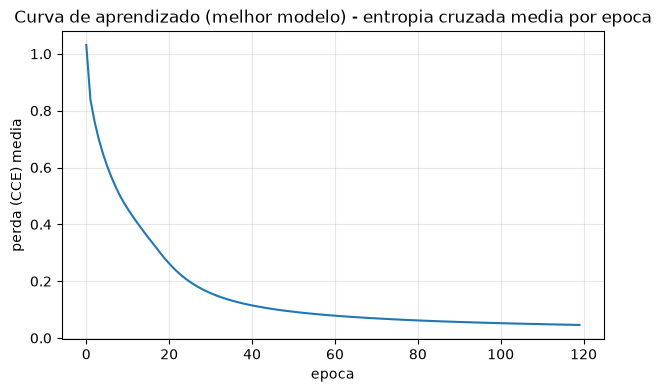

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(best_history)
plt.title('Curva de aprendizado (melhor modelo) - entropia cruzada media por epoca')
plt.xlabel('epoca')
plt.ylabel('perda (CCE) media')
plt.grid(True, alpha=0.3)
plt.show()

## 6. Avaliação final no conjunto de teste

Avaliamos o melhor modelo no conjunto de teste (não usado em nenhuma decisão até aqui), com a matriz de confusão 3x3 e as métricas por classe e macro.

In [7]:
test_pred = predict_classes(best_model, X_test)
cm = confusion_matrix(labels_test, test_pred, n_classes)
precision, recall, f1 = per_class_metrics(cm)
accuracy = accuracy_from_cm(cm)

print(f'acuracia (teste): {accuracy:.4f}')
print()
print('metricas por classe:')
for c in range(n_classes):
    print(f'  {class_names[c]:<12} precisao={precision[c]:.3f} revocacao={recall[c]:.3f} f1={f1[c]:.3f}')
print()
print(f'macro:          precisao={precision.mean():.3f} revocacao={recall.mean():.3f} f1={f1.mean():.3f}')

acuracia (teste): 0.9667

metricas por classe:
  setosa       precisao=1.000 revocacao=1.000 f1=1.000
  versicolor   precisao=1.000 revocacao=0.833 f1=0.909
  virginica    precisao=0.917 revocacao=1.000 f1=0.957

macro:          precisao=0.972 revocacao=0.944 f1=0.955


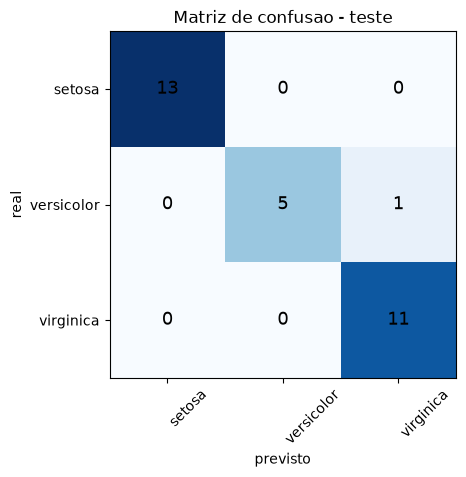

In [8]:
# matriz de confusao 3x3 como mapa de calor
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.matshow(cm, cmap='Blues')
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, str(value), ha='center', va='center', fontsize=13)
ax.set_xticks(range(n_classes)); ax.set_xticklabels(class_names, rotation=45, ha='left')
ax.set_yticks(range(n_classes)); ax.set_yticklabels(class_names)
ax.xaxis.set_ticks_position('bottom')
ax.set_xlabel('previsto'); ax.set_ylabel('real')
ax.set_title('Matriz de confusao - teste')
plt.show()

## 7. Conclusão

A rede neural MLP implementada do zero classifica as três espécies de Iris com alta acurácia no conjunto de teste.

Pontos importantes:

- A saída **softmax + entropia cruzada categórica** é o par natural para classificação multiclasse: a softmax produz uma distribuição de probabilidade sobre as 3 classes, e a previsão é o `argmax`.
- A maioria dos erros (quando ocorrem) fica entre **versicolor** e **virginica**, que são as classes menos separáveis — visível na matriz de confusão. A *setosa* é linearmente separável e costuma ser classificada perfeitamente.
- O **conjunto de validação** guiou a escolha da taxa de aprendizado, e o **teste** foi usado uma única vez na avaliação final.